**Project Name :** Book Recommendation System

**Project Objective:**

*   This project is all about recomendation system.
*   In this project we have tried to use some approches for recomending the  
    books to the readers or users.
*   We will be using various ways such as collaborative Filtering and Content based
    Filtering for recomendation of the books to the users .



    



**Dataset:**

*   We have three different datsets namely book.csv which contains information
    about the books such as book-author , publisher , book title , year of publication, image links and unique Book ID i.e ISBN Number .
*   Then we have ratings.csv which contain information about ratings given by
    the users for the books, it contains user ID ,ISBN number and book rating (scale between 1-10).
*   Then we have users.csv which contain information about users such as their
    location , age and their user ID.   






**Importing necessary libraries**

In [6]:
# for dealing with regular expression techniques
import re
import requests
import random
#for NLP related tasks
from sklearn.feature_extraction.text import CountVectorizer
import nltk

# basic libraries
import pandas as pd
import numpy as np


import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
#for TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
# for finding similarity
from sklearn.metrics.pairwise import cosine_similarity

import scipy
import math
import sklearn
#for removing stopwords
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
#for SVD model
from scipy.sparse.linalg import svds
# for plotting graphs
import matplotlib.pyplot as plt



**Loading the datasets**

In [8]:
df_books = pd.read_csv('../data/Books.csv', encoding='latin-1')
df_books

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


In [18]:
df_ratings = pd.read_csv('../data/Ratings.csv', encoding='latin-1')
df_ratings

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


In [17]:
df_users = pd.read_csv('../data/Users.csv', encoding='latin-1')
df_users

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN
...,...,...,...
278853,278854,"portland, oregon, usa",NaN
278854,278855,"tacoma, washington, united kingdom",50.0
278855,278856,"brampton, ontario, canada",NaN
278856,278857,"knoxville, tennessee, usa",NaN


**Basic dataset information**

In [10]:
df_books.info()
df_books.columns

<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  str   
 1   Book-Title           271360 non-null  str   
 2   Book-Author          271358 non-null  str   
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  str   
 5   Image-URL-S          271360 non-null  str   
 6   Image-URL-M          271360 non-null  str   
 7   Image-URL-L          271357 non-null  str   
dtypes: object(1), str(7)
memory usage: 83.4+ MB


Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='str')

In [ ]:
df_ratings.info()
df_ratings.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='object')

In [19]:
df_users.info()
df_users.columns

<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 13.4 MB


Index(['User-ID', 'Location', 'Age'], dtype='str')

In [ ]:
df_books.describe()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
count,271360,271360,271358,271360,271358,271360,271360,271357
unique,271360,242135,102022,202,16807,271044,271044,271041
top,0195153448,Selected Poems,Agatha Christie,2002,Harlequin,http://images.amazon.com/images/P/185326119X.0...,http://images.amazon.com/images/P/185326119X.0...,http://images.amazon.com/images/P/225307649X.0...
freq,1,27,632,13903,7535,2,2,2


In [20]:
df_ratings.describe()

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


In [ ]:
df_users.describe()

,User-ID,Age
count,278858.00000,168096.000000
mean,139429.50000,34.751434
std,80499.51502,14.428097
min,1.00000,0.000000
25%,69715.25000,24.000000
50%,139429.50000,32.000000
75%,209143.75000,44.000000
max,278858.00000,244.000000


**Unique Values**

In [13]:
df_books.nunique()

ISBN                   271360
Book-Title             242135
Book-Author            102022
Year-Of-Publication       202
Publisher               16807
Image-URL-S            271044
Image-URL-M            271044
Image-URL-L            271041
dtype: int64

In [ ]:
df_ratings.nunique()

,0
User-ID,105283
ISBN,340556
Book-Rating,11


In [ ]:
df_users.nunique()

,0
User-ID,278858
Location,57339
Age,165


**Duplicate Values**

In [21]:
print("Duplicate Values in BOOKS", len(df_books[df_books.duplicated()]))
print("Duplicate Values in RATINGS", len(df_ratings[df_ratings.duplicated()]))
print("Duplicate Values in USERS", len(df_users[df_users.duplicated()]))

Duplicate Values in BOOKS 0
Duplicate Values in RATINGS 0
Duplicate Values in USERS 0


**Finding and handling missing values**

NULL Values in BOOKS ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64


<Figure size 1000x600 with 0 Axes>

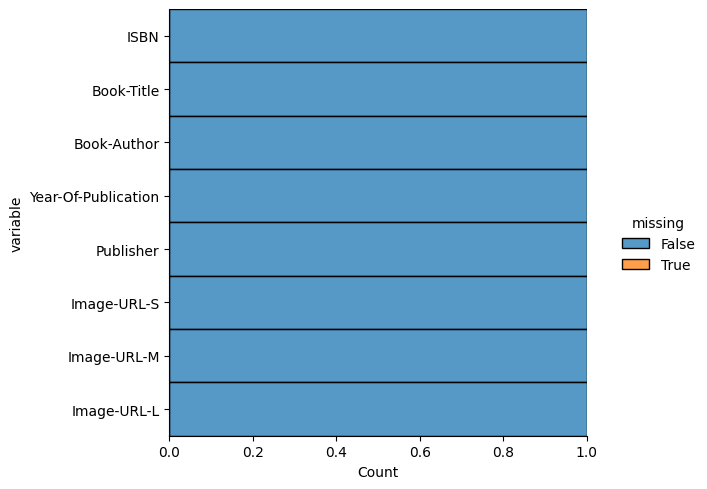

In [22]:
print("NULL Values in BOOKS" ,df_books.isnull().sum())
# Visualizing the missing values
plt.figure(figsize=(10,6))
sns.displot(
    data=df_books.isnull().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)

NULL Values in RATINGS  User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


<Figure size 1000x600 with 0 Axes>

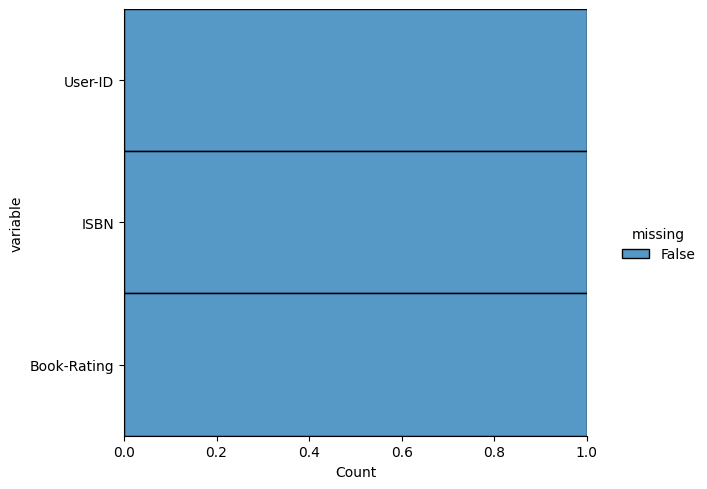

In [23]:
print("NULL Values in RATINGS ",df_ratings.isnull().sum())
# Visualizing the missing values
plt.figure(figsize=(10,6))
sns.displot(
    data=df_ratings.isnull().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)

NULL Values in USERS User-ID          0
Location         0
Age         110762
dtype: int64


<Figure size 1000x600 with 0 Axes>

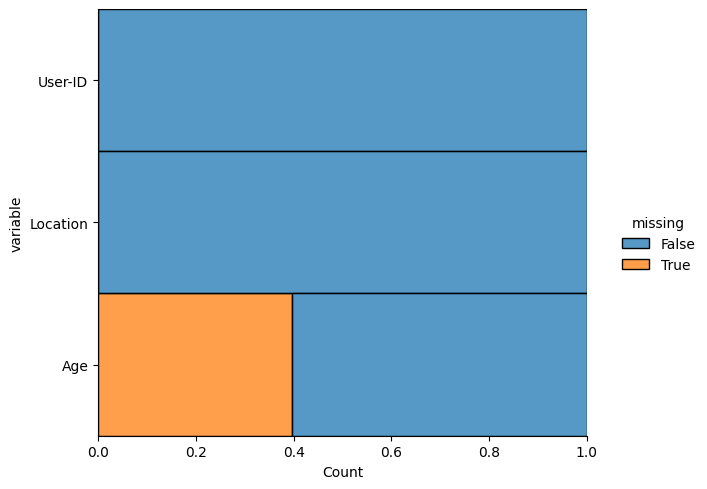

In [24]:
print("NULL Values in USERS",df_users.isnull().sum())
# Visualizing the missing values
plt.figure(figsize=(10,6))
sns.displot(
    data=df_users.isnull().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)

**Handling missing values**

In [25]:
df_users["Age"].fillna(df_users.Age.median(),inplace=True)
print("NULL Values in USERS",df_users.isnull().sum())

NULL Values in USERS User-ID          0
Location         0
Age         110762
dtype: int64


**Fixing wrong values**

In [26]:
df_books['Year-Of-Publication'].unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984, 0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, '2000', '1995', '1999', '2004',
       '2003', '1990', '1994', '1986', '1989', '2002', '1981', '1993',
       '1983', '1982', '1976', '1991', '1977', '1998', '1992', '1996',
       '0', '1997', '2001', '1974', '1968', '1987', '1984', '1988',
       '1963', '1956', '1970', '1985', '1978', '1973', '1980'

In [27]:
# checking the data where the 'Year-Of-Publication' is 'DK Publishing Inc'
df_books.loc[df_books['Year-Of-Publication'] == 'DK Publishing Inc',:]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


In [28]:
#Fixing the wrongly inputed values
#ISBN '0789466953'
df_books.loc[df_books.ISBN == '0789466953','Year-Of-Publication'] = 2000
df_books.loc[df_books.ISBN == '0789466953','Book-Author'] = "James Buckley" # this we gathered from the google
df_books.loc[df_books.ISBN == '0789466953','Publisher'] = "DK Publishing Inc"
df_books.loc[df_books.ISBN == '0789466953','Book-Title'] = "DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)"

#ISBN '078946697X'
df_books.loc[df_books.ISBN == '078946697X','Year-Of-Publication'] = 2000
df_books.loc[df_books.ISBN == '078946697X','Book-Author'] = "Michael Teitelbaum" # this we gathered from the google
df_books.loc[df_books.ISBN == '078946697X','Publisher'] = "DK Publishing Inc"
df_books.loc[df_books.ISBN == '078946697X','Book-Title'] = "DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)"

In [29]:
# checking for the Gallimard
df_books.loc[df_books['Year-Of-Publication'] == 'Gallimard',:]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN


In [30]:
df_books.loc[df_books.ISBN == '2070426769','Year-Of-Publication'] = 2003
df_books.loc[df_books.ISBN == '2070426769','Book-Author'] = "Jean-Marie Gustave Le ClÃ?Â©zio"
df_books.loc[df_books.ISBN == '2070426769','Publisher'] = "Gallimard"
df_books.loc[df_books.ISBN == '2070426769','Book-Title'] = "Peuple du ciel, suivi de 'Les Bergers"

In [31]:
df_books['Year-Of-Publication'].unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984, 0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, '2000', '1995', '1999', '2004',
       '2003', '1990', '1994', '1986', '1989', '2002', '1981', '1993',
       '1983', '1982', '1976', '1991', '1977', '1998', '1992', '1996',
       '0', '1997', '2001', '1974', '1968', '1987', '1984', '1988',
       '1963', '1956', '1970', '1985', '1978', '1973', '1980'

In [32]:
df_books["Book-Author"].fillna("other", inplace = True)
df_books["Publisher"].fillna("other", inplace = True)

0                                  Oxford University Press
1                                    HarperFlamingo Canada
2                                          HarperPerennial
3                                     Farrar Straus Giroux
4                               W. W. Norton &amp; Company
                                ...                       
271355                     Random House Childrens Pub (Mm)
271356                                        Dutton Books
271357                                  HarperSanFrancisco
271358                             Oxford University Press
271359    McGraw-Hill Humanities/Social Sciences/Languages
Name: Publisher, Length: 271360, dtype: str

**Handling Outliers**

<Axes: xlabel='Age'>

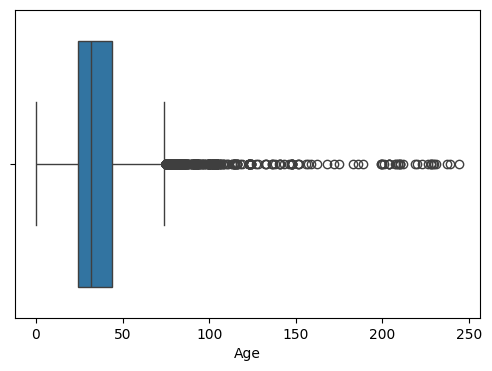

In [33]:
# Handling Outliers & Outlier treatments
Q3,Q1 = np.percentile(df_users['Age'],[75,25])
#Calculating Inter Quartile Range
IQR = Q3-Q1
#Fixing Boundaries for outliers
max = Q3+(1.5*IQR)
min = Q1-(1.5*IQR)
df_users["Age"] = np.where(df_users["Age"] > max, max, df_users['Age'])
df_users["Age"] = np.where(df_users["Age"] < min, min, df_users['Age'])

# chceking the outliers again
fig = plt.figure(figsize=(6,4))
sns.boxplot(x='Age',data=df_users)

**Visualizations**

In [34]:
# Merge the dataset

df_books_rating=df_books.merge(df_ratings,on="ISBN")
df_books_rating.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,User-ID,Book-Rating
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,2,0
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,8,5
2,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11400,0
3,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11676,8
4,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,41385,0


In [36]:
# Dropping unnecessary columns

df_books_rating_copy=df_books_rating.copy()
# removing null values
df_books_rating_copy.dropna(inplace=True)
df_books_rating_copy.reset_index(drop=True,inplace=True)


# as the columns ISBN has no use for the analysis also Year-Of-publication
# we can also remove the medium and small scale of a image link i.e Image-URL-S and Image-URL-M
df_books_rating_copy.drop(columns=["ISBN","Year-Of-Publication","Image-URL-S","Image-URL-M"],inplace=True)

# we can also drop the book details where the ratings is 0 as it is not a valid rating
df_books_rating_copy.drop(index=df_books_rating_copy[df_books_rating_copy["Book-Rating"]==0].index,inplace=True)

df_books_rating_copy["Book-Title"]=df_books_rating_copy["Book-Title"].apply(lambda x: re.sub("[\W_]+"," ",x).strip())
df_books_rating_copy.head()

,Book-Title,Book-Author,Publisher,Image-URL-L,User-ID,Book-Rating
1,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,8,5
3,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,11676,8
5,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,67544,8
8,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,116866,9
9,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,123629,9


Text(0.5, 1.0, 'Top 20 author with number of books')

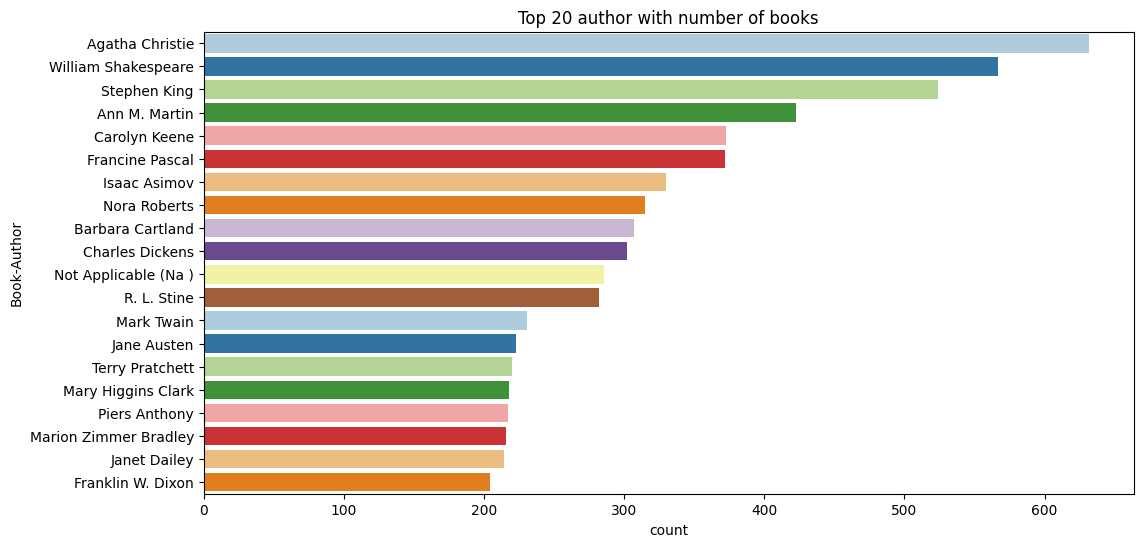

In [37]:
# Chart - 1 Top 20 author with number of books
plt.figure(figsize=(12,6))
sns.countplot(y="Book-Author",palette = 'Paired', data=df_books,order=df_books['Book-Author'].value_counts().index[0:20])
plt.title("Top 20 author with number of books")

Text(0.5, 1.0, 'Ratings')

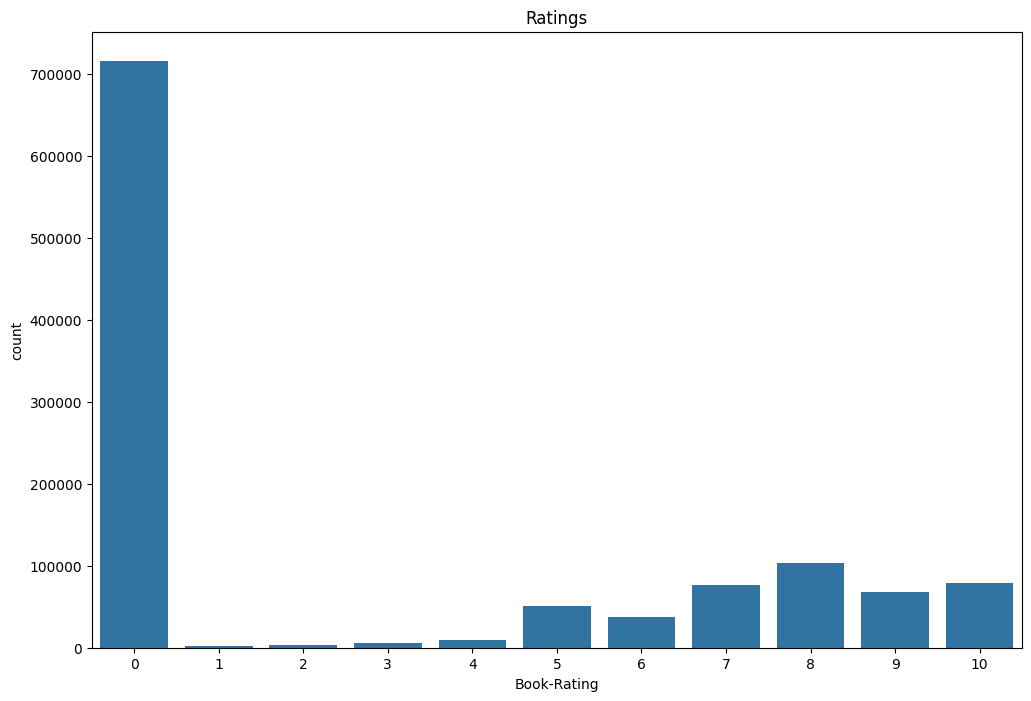

In [38]:
# Chart - 2 Plotting the rating column distribusion
plt.figure(figsize=(12,8))
sns.countplot(x="Book-Rating", data=df_ratings)
plt.title("Ratings")

In [39]:
# Finding percentage of books having 0 rating

Books_zero_rating = (len(df_books_rating[df_books_rating["Book-Rating"]==0])/len(df_books_rating))*100
print('Percentage of books with zero rating %0.2f' % Books_zero_rating)

Percentage of books with zero rating 62.77


In [40]:
# Chart - 3 Top 10 Books with highest nuumber of ratings
valid_rating=df_ratings[df_ratings['Book-Rating'] != 0]
top10_ratings=valid_rating.groupby('ISBN')['Book-Rating'].count().sort_values(ascending=False).head(10)
top10_ratings

ISBN
0316666343    707
0971880107    581
0385504209    487
0312195516    383
0679781587    333
0060928336    320
059035342X    313
0142001740    307
0446672211    295
044023722X    281
Name: Book-Rating, dtype: int64

Text(0.5, 1.0, 'Age Distribution Plot')

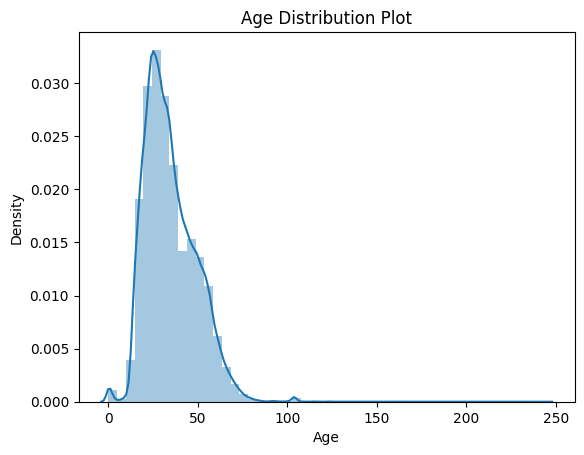

In [41]:
# Chart - 4 User Age distribution
sns.distplot(df_users.Age)
plt.title('Age Distribution Plot')

<Axes: xlabel='Age'>

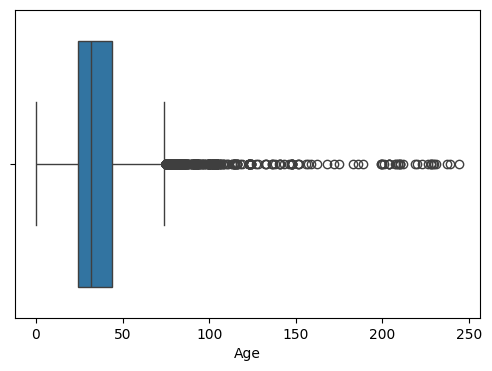

In [42]:
# Chart - 5 Checking Outliers for the Users Age column
fig = plt.figure(figsize=(6,4))
sns.boxplot(x='Age',data=df_users)

Text(0.5, 1.0, 'Top 20 author with maximum number of rating')

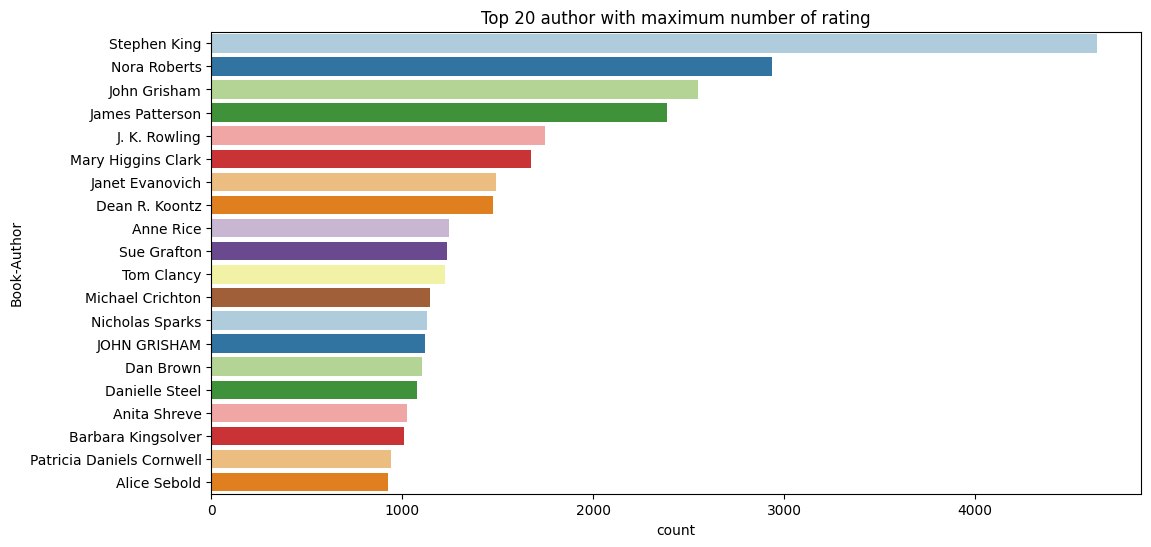

In [43]:
# Chart - 6 Top 20 authors with maximum number of ratings
plt.figure(figsize=(12,6))
sns.countplot(y="Book-Author",palette = 'Paired', data=df_books_rating_copy,order=df_books_rating_copy['Book-Author'].value_counts().index[0:20])
plt.title("Top 20 author with maximum number of rating")

<Axes: xlabel='Book-Title'>

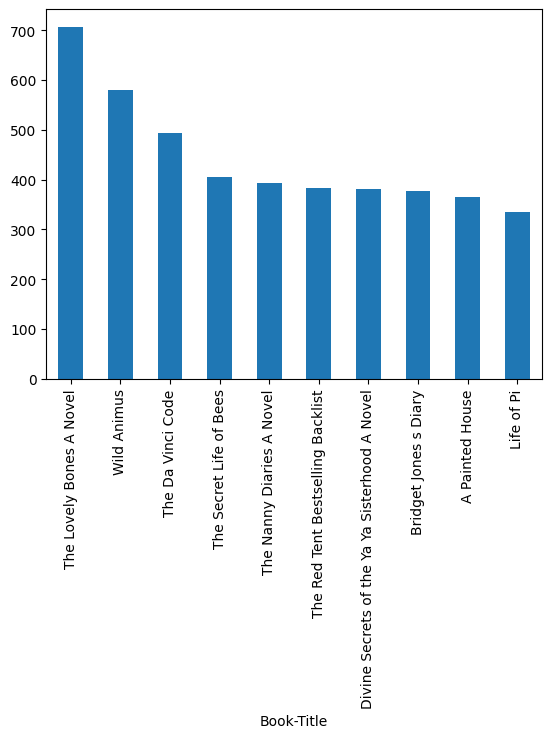

In [44]:
# Chart - 7 Top 10 books which got highest numbers of rating
df_books_rating_copy.groupby(['Book-Title'])['Book-Rating'].count().sort_values(ascending=False).head(10).plot(kind='bar')

Text(0.5, 1.0, "Top 10 'Publisher' with maximum number of rating")

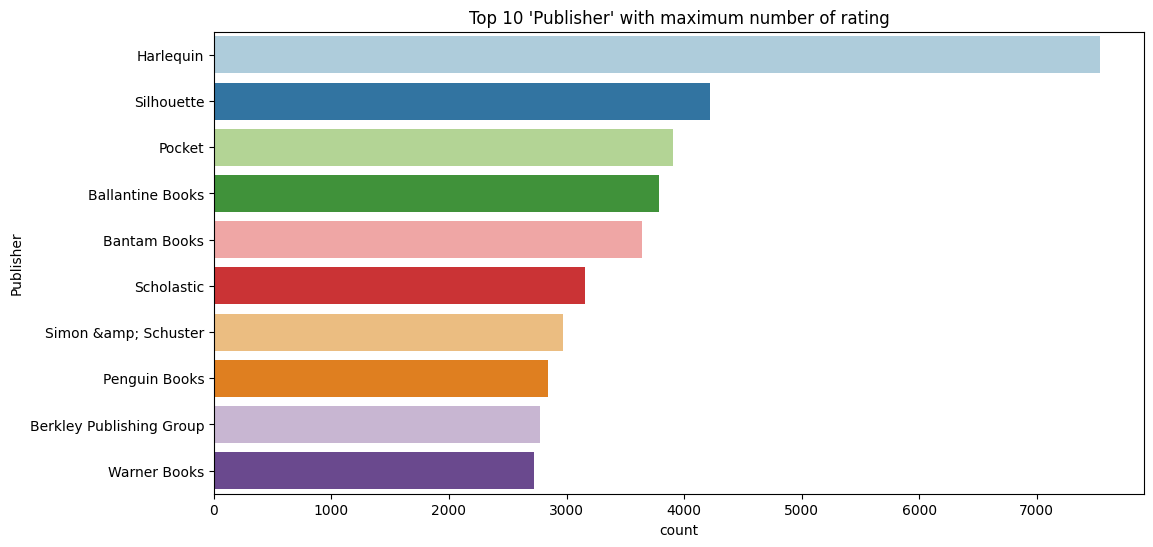

In [45]:
# Chart - 8 Top 10 publishers with maximum number of ratings
plt.figure(figsize=(12,6))
sns.countplot(y='Publisher',palette = 'Paired', data=df_books,order=df_books['Publisher'].value_counts().index[0:10])
plt.title("Top 10 'Publisher' with maximum number of rating")

**EDA ANALYSIS**

1. Average age of users is between 34-35.
2. Average rating given by users is 2.8.
3. Outliers have been handled using IQR method.
4. Missing values have been handled by replacing data with median values.
5. Wrong data in wrong columns has been handled.
6. Hariequin, Silhouette and Pocket are the top 3 publishers.
7. Books like The Lovely Bone and Wild Animus are the 2 top rated books.
8. Stephen King, Nora Roberts and John Grisham are the top 3 authors.
9. Agatha Christie, William Shakespeare and Stephen King released maximum books.
10. 62.77 percent books have 0 rating.

**MODEL BUILDING**

Popularity Based Approach

The main idea behind Popularity Based Approach is to recomend the books which are popular , the popularity can be calculated on the basis of ratings

In [46]:
def popularity_approach(df,number_of_top_book=50):
    # first we have groupy with Book-Ttle and Book-rating as we wou recomend popularity on the these columns
    rating_counts=df.groupby("Book-Title").count()["Book-Rating"].reset_index()
    # counting the number of ratings that particular book-title has got
    rating_counts.rename(columns={"Book-Rating":"num_of_ratings"},inplace=True)

    # calculating average rating
    rating_avg=df.groupby("Book-Title")["Book-Rating"].mean().reset_index()
    rating_avg.rename(columns={"Book-Rating":"average_rating"},inplace=True)

    df_popular_books=rating_counts.merge(rating_avg,on="Book-Title")

    # average rating can be misguiding as they may be baised to number of ratings
    # so taking account of number of ratings for particular book-title
    # therefore  creating a function for calculating meaningfull average rating
    mean_avg_rating=df_popular_books["average_rating"].mean()
    total_ratings=df_popular_books["num_of_ratings"].quantile(0.90)
    def weighted_rate(df):
        number_of_rating_vector=df["num_of_ratings"]
        average_rating_vector=df["average_rating"]

        return ((number_of_rating_vector*average_rating_vector) + (total_ratings*mean_avg_rating)) / (number_of_rating_vector+total_ratings)


    # checking only for books which got more than
    df_popular_books=df_popular_books[df_popular_books["num_of_ratings"] >=100]
    # calculating popularity of books using weighted_rate
    df_popular_books["popularity"]=df_popular_books.apply(weighted_rate,axis=1)
    # sorting the books by its popularity in decending order
    df_popular_books=df_popular_books.sort_values(by="popularity",ascending=False)
    # returning the top n books
    return df_popular_books[["Book-Title","num_of_ratings","average_rating","popularity"]].reset_index(drop=True).head(number_of_top_book)

In [47]:
# top 20 popular books
top_20=pd.DataFrame(popularity_approach(df_books_rating_copy,20))
top_20

,Book-Title,num_of_ratings,average_rating,popularity
0,The Two Towers The Lord of the Rings Part 2,136,9.330882,9.266739
1,The Return of the King The Lord of the Rings P...,105,9.228571,9.151001
2,Harry Potter and the Goblet of Fire Book 4,247,9.125506,9.093691
3,Harry Potter and the Sorcerer s Stone Book 1,176,9.062500,9.019946
4,Harry Potter and the Prisoner of Azkaban Book 3,277,9.043321,9.016348
5,Harry Potter and the Order of the Phoenix Book 5,211,9.047393,9.012084
6,To Kill a Mockingbird,267,8.977528,8.950773
7,Harry Potter and the Sorcerer s Stone Harry Po...,315,8.936508,8.914407
8,Ender s Game Ender Wiggins Saga Paperback,151,8.920530,8.875706
9,The Fellowship of the Ring The Lord of the Rin...,205,8.882927,8.850524


**COLLABORATIVE FILTERING**

In Collaborative Filtering we make predictions of the taste or the intrests of the user based based on the other similar users behaviour (which is called collaborative) .The simple understanding is that if a person P1 have similar opinion with person P2 , then if person P1 is reading Harry Potter books then person P2 may also read Harry Potter books

Collaborative Filtering has mainly two implimentaion strategies
*   Model Based
*   Memory Based

we will use following approaches
*  User_based Collaborative Filtering and
*  Item_based Collaborative Filtering

* Content Based Filtering

**User Based Collaborative Filtering**

In this technique we try to predict on basis of what user may like based on the ratings that they had given to the items. In simpe words here we try to indentify the neghbouring users on the basis of similarity of active users and then scoring of the items is calculated on the basis of those neighbour users

In [48]:
# Drop users who have given less number of votings
# we will drop the users where the number of votes are less than 100
new_df=df_books_rating_copy[df_books_rating_copy['User-ID'].map(df_books_rating_copy['User-ID'].value_counts()) > 100]

# creating a pivot tables consisting user realted information
users_info=new_df.pivot_table(index=["User-ID"],columns=["Book-Title"],values="Book-Rating")
users_info.fillna(0,inplace=True)

users_info.head(3)

Book-Title,01 01 00 A Novel of the Millennium,01 01 00 The Novel of the Millennium,1 000 Makers of the Millennium The Men and Women Who Have Shaped the Last 1 000 Years,1 000 Places to See Before You Die,1 000 Years 1 000 People Ranking the Men and Women Who Shaped the Millennium,1 001 Health Tips,1 001 Old Time Garden Tips Timeless Bits of Wisdom on How to Grow Everything Organically from the Good Old Days When Everyone Did,1 003 Great Things About Kids,1 2 3 Magic Effective Discipline for Children 2 12,1 2 3 Music,...,the Devil Will Drag You Under,them Modern Library,together by christmas,wet sand raven tracks,whataboutrick com a poetic tribute to Richard A Ricci,y los 40 ladrones ColecciÃ³n FÃ bula,Â Corre perro corre,Â Eres tu mi mamÃ Are You My Mother,Ã ngeles fugaces Falling Angels,Ã Â ber das Fernsehen
User-ID,,,,,,,,,,,,,,,,,,,,,
2033,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2110,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2276,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
def choice_of_users(id):

    user_favourite=new_df[new_df["User-ID"]==id].sort_values(["Book-Rating"],ascending=False)[0:10]
    return user_favourite

def user_based_collaborative(new_df,user_id):
    if user_id not in new_df["User-ID"].values:
        print("USER NOT FOUND")


    else:
        user_index=np.where(users_info.index==user_id)[0][0]
        similar=cosine_similarity(users_info)
        similar_users_list=list(enumerate(similar[user_index]))
        similar_users_list = sorted(similar_users_list,key = lambda x:x[1],reverse=True)[0:10]

        record_of_users=[]

        for ind in similar_users_list:
                data=df_books_rating_copy[df_books_rating_copy["User-ID"]==users_info.index[ind[0]]]
                record_of_users.extend(list(data.drop_duplicates("User-ID")["User-ID"].values))

    return record_of_users

def common(df,users_list,user_id):
    temp1=new_df[df["User-ID"]==user_id]
    suggested_books=[]
    users_list=list(users_list)
    for id in users_list:
        temp2=df[(df["User-ID"]==id)]
        all_books=temp2.loc[~temp2["Book-Title"].isin(temp1["Book-Title"]),:]
        all_books=all_books.sort_values(["Book-Rating"],ascending=False)[0:10]
        suggested_books.extend(all_books["Book-Title"].values)

    return suggested_books[0:10]

In [50]:
# taking any random user_id
random_user_id=random.choice(new_df["User-ID"].values)
# showing users choice based on history
user_choice=pd.DataFrame(choice_of_users(random_user_id))
# subseting users favourite from users choice
user_favorite=choice_of_users(random_user_id)
n=len(user_choice["Book-Title"].values)
print(f"USER: {random_user_id} ")

USER: 179978 


In [51]:
user_favorite

,Book-Title,Book-Author,Publisher,Image-URL-L,User-ID,Book-Rating
6922,The Tao of Pooh,Benjamin Hoff,Penguin Books,http://images.amazon.com/images/P/0140067477.0...,179978,10
44568,The Carousel A Novel,Richard Paul Evans,Simon &amp; Schuster,http://images.amazon.com/images/P/0684868911.0...,179978,10
452386,What to Expect the Toddler Years,Arlene Eisenberg,Workman Publishing,http://images.amazon.com/images/P/0894809946.0...,179978,10
79259,What to Expect the First Year,Arlene Eisenberg,Workman Publishing,http://images.amazon.com/images/P/0894805770.0...,179978,10
99475,People of the Mist The First North Americans s...,Kathleen O'Neal Gear,Tor Books,http://images.amazon.com/images/P/0812515609.0...,179978,10
114804,Harry Potter and the Sorcerer s Stone Book 1,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0590353403.0...,179978,10
121646,The Dance,Richard Paul Evans,Simon &amp; Schuster Children's Publishing,http://images.amazon.com/images/P/0689823517.0...,179978,10
140457,The Cat in the Hat,Dr. Seuss,Random House Books for Young Readers,http://images.amazon.com/images/P/039480001X.0...,179978,10
142610,Harry Potter and the Prisoner of Azkaban Book 3,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0439136350.0...,179978,10
180698,Harry Potter and the Goblet of Fire Book 4,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0439139597.0...,179978,10


In [52]:
# getting user based data for particular random user id
user_based=user_based_collaborative(new_df,random_user_id)
# getting recomended books for that particular random user id
book_suggesions_user=common(new_df,user_based,random_user_id)
# ceating a dataframe to store the results
book_suggesions_user=pd.DataFrame(book_suggesions_user,columns=["Book-Title"])
book_suggesions_user

,Book-Title
0,The Grapes of Wrath John Steinbeck Centennial ...
1,Chemistry
2,Thirty Five Thousand Plus Baby Names The Large...
3,Kushiel s Dart
4,Daughter of the Blood Black Jewels Trilogy
5,Queen of the Darkness Black Jewels Trilogy
6,In Home Child Care A Step By Step Guide to Qua...
7,Kushiel s Chosen Kushiel s Legacy
8,Essentials of Computational Chemistry Theories...
9,The Calvin and Hobbes Tenth Anniversary Book


**Item Based Collaborative Filtering**

In Item based collaborative filtering we try to find similar items based on the items whichs user has liked or interacted with .It suggests an item based on items the user has previously consumed. It looks for the items the user has consumed then it finds other items similar to consumed items and recommends accordingly

In [57]:
from sklearn.metrics.pairwise import cosine_similarity

def item_based_approach(data, query_bookTitle, number_of_suggestions):

    # Count ratings per book
    count_rating = data["Book-Title"].value_counts()

    # Remove rare books (<=100 ratings)
    rare = count_rating[count_rating <= 100].index
    common_books = data[~data["Book-Title"].isin(rare)]

    # Create pivot table
    pt = common_books.pivot_table(
        index='Book-Title',
        columns='User-ID',
        values='Book-Rating'
    ).fillna(0)

    # Compute similarity
    similarity = cosine_similarity(pt)

    # 🔥 Flexible matching (IMPORTANT)
    matches = [book for book in pt.index if query_bookTitle.lower() in book.lower()]

    if len(matches) == 0:
        return "Book not found"

    # Use best match
    query_bookTitle = matches[0]

    # Find index
    index = list(pt.index).index(query_bookTitle)

    # Get similar books
    scores = list(enumerate(similarity[index]))
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:number_of_suggestions+1]

    # Get recommendations
    recommendations = [pt.index[i[0]] for i in sorted_scores]

    return recommendations

In [58]:
# getting top 10 suggesions from item-based approach
item_based_approach(df_books_rating_copy, 'Beloved', 10)

'Book not found'

**Model Based Approach**

Singular Value Decomposition (SVD), is a popular method in field of Data Science and Machine Learning .It is a classical method from the Linear Algebra concept. It is popular beacuse of its properties and its use in Recomendation System. We can use this in recomending Books, movies etc.

SVD is a method from linear algebra that has been generally used as a dimensionality reduction technique in ML problems. It is a matrix Factorisation technique which tries to reduce the number of feature or attributes by reducing the sapce dimension from N dimension to I dimension.SVD is used as a collaborative filtering technique in recomendation technique domain. It consist of a matrix structure where the rows define the users and columns defines the item.

Non- Negetive Matrix Factorisation(NMF) : Our goal in NMF is to approximate the users-item V matrix by the dot product of two arrays W and H. Dimensions of the arrays are defined by dimensions of V and number of components we set to the algorithm. If V has n rows and m columns and we want to decompose it to k components, then W has n rows, and k columns and H has k rows and m columns.This is actually matrix factorization part of the algorithm. The Non-negative part refers to V, W, and H — all the values have to be equal or greater than zero, i.e., non-negative.

In [59]:
# cosidering valid ratings only
df_ratings=df_ratings[df_ratings['Book-Rating'] != 0]
df_merge=pd.merge(df_users, df_ratings, on="User-ID")
df_merge=pd.merge(df_merge,df_books, on="ISBN")
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 383842 entries, 0 to 383841
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   User-ID              383842 non-null  int64  
 1   Location             383842 non-null  str    
 2   Age                  269621 non-null  float64
 3   ISBN                 383842 non-null  str    
 4   Book-Rating          383842 non-null  int64  
 5   Book-Title           383842 non-null  str    
 6   Book-Author          383840 non-null  str    
 7   Year-Of-Publication  383842 non-null  object 
 8   Publisher            383840 non-null  str    
 9   Image-URL-S          383842 non-null  str    
 10  Image-URL-M          383842 non-null  str    
 11  Image-URL-L          383841 non-null  str    
dtypes: float64(1), int64(2), object(1), str(8)
memory usage: 136.8+ MB


In [60]:
df_merge.drop(['Image-URL-M','Image-URL-S','Image-URL-L'],axis=1,inplace=True)

In [61]:
df_merge.isnull().sum()

User-ID                     0
Location                    0
Age                    114221
ISBN                        0
Book-Rating                 0
Book-Title                  0
Book-Author                 2
Year-Of-Publication         0
Publisher                   2
dtype: int64

In [66]:
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Filter active users (LESS STRICT)
x = df_books_rating_copy.groupby('User-ID').count()['Book-Rating'] > 50
active_users = x[x].index
filtered_rating = df_books_rating_copy[df_books_rating_copy['User-ID'].isin(active_users)]

# Step 2: Filter popular books (LESS STRICT)
y = filtered_rating.groupby('Book-Title').count()['Book-Rating'] > 10
popular_books = y[y].index
final_df = filtered_rating[filtered_rating['Book-Title'].isin(popular_books)]

# Step 3: Create pivot table
pt = final_df.pivot_table(
    index='Book-Title',
    columns='User-ID',
    values='Book-Rating'
).fillna(0)

print("Pivot shape:", pt.shape)  # 🔍 check

# Step 4: Compute similarity
similarity = cosine_similarity(pt)

# Step 5: Recommendation function
def recommend(book_name):
    matches = [book for book in pt.index if book_name.lower() in book.lower()]
    
    if len(matches) == 0:
        return "Book not found"
    
    book_name = matches[0]
    index = list(pt.index).index(book_name)
    
    distances = sorted(list(enumerate(similarity[index])), reverse=True, key=lambda x: x[1])[1:6]
    
    return [pt.index[i[0]] for i in distances]

# Step 6: Test
print(recommend("Beloved"))



Pivot shape: (1473, 1128)
['Where the Heart Is', 'Untamed', 'The Conquest', 'Patty Jane s House of Curl Ballantine Reader s Circle', 'Blindness Harvest Book']


In [69]:
pt = final_df.pivot_table(
    index='Book-Title',
    columns='User-ID',
    values='Book-Rating'
).fillna(0)

from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(pt)

**Cross- Validation & Hyperparameter Tuning**

As SVD model is working good with deafault parameters so, we would try hypertunning on SVD model only

Hyperparameter tunning is a process where we tune our model that is we try to find the odel parameters which would give best results

Here we have use GridSearchCV which check the results for all possible combination from the parameter grid

we will try to find the model parameters

      'n_factors'- number of factors
      'n_epochs'- number of epochs i.e number of iteration of the SVD procedure
      'lr_all'- learning rate
      'reg_all- the regularisation term for all parameters

In [71]:
pt = final_df.pivot_table(
    index='Book-Title',
    columns='User-ID',
    values='Book-Rating'
).fillna(0)

from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(pt)

**Hypertunning SVD model**

In [73]:
# Pivot table
pt = final_df.pivot_table(
    index='Book-Title',
    columns='User-ID',
    values='Book-Rating'
).fillna(0)

# Similarity
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(pt)

In [77]:
# Test recommendations
book_name = "Beloved"
recs = recommend(book_name)

print(f"Recommendations for {book_name}:\n")
for i, book in enumerate(recs, 1):
    print(f"{i}. {book}")

Recommendations for Beloved:

1. Where the Heart Is
2. Untamed
3. The Conquest
4. Patty Jane s House of Curl Ballantine Reader s Circle
5. Blindness Harvest Book


In [80]:
import pickle

# Save pivot table
pickle.dump(pt, open('../model/books.pkl', 'wb'))

# Save similarity matrix
pickle.dump(similarity, open('../model/similarity.pkl', 'wb'))

**MODEL EVALUATION**

SVD model works better than NMF model as it has lower RMSE and MAE score.